In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

df = pd.read_csv("../f1_clean.csv")

FEATURES = ['grid', 'laps', 'points', 'fastestLapSpeed']
df = df.dropna(subset=FEATURES).reset_index(drop=True)

X = df[FEATURES].values
y = df['podium'].values

print(f"Dataset: {X.shape}")
print(f"Class balance:")
print(f"  No podium (0): {(y==0).sum()}  ({(y==0).mean()*100:.1f}%)")
print(f"  Podium    (1): {(y==1).sum()}  ({(y==1).mean()*100:.1f}%)")
print()

Dataset: (5302, 4)
Class balance:
  No podium (0): 4393  (82.9%)
  Podium    (1): 909  (17.1%)



In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)

X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}  Test: {X_test_s.shape}")
print(f"Train podium rate: {y_train.mean()*100:.1f}%")
print(f"Test  podium rate: {y_test.mean()*100:.1f}%")
print()


Train: (4241, 4)  Test: (1061, 4)
Train podium rate: 17.1%
Test  podium rate: 17.2%



In [3]:
k_values = range(1, 31)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean',
        weights='uniform'
    )
    scores = cross_val_score(knn, X_train_s, y_train, cv=5, scoring='roc_auc')
    cv_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_scores)]
print(f"Best K = {best_k}  (CV AUC = {max(cv_scores):.3f})")
print()
print("All K values and their CV AUC scores:")
for k, s in zip(k_values, cv_scores):
    bar = '█' * int(s * 40)
    marker = ' ← best' if k == best_k else ''
    print(f"  K={k:2d}  {s:.3f}  {bar}{marker}")


Best K = 7  (CV AUC = 1.000)

All K values and their CV AUC scores:
  K= 1  0.984  ███████████████████████████████████████
  K= 2  0.995  ███████████████████████████████████████
  K= 3  0.997  ███████████████████████████████████████
  K= 4  0.997  ███████████████████████████████████████
  K= 5  0.999  ███████████████████████████████████████
  K= 6  1.000  ███████████████████████████████████████
  K= 7  1.000  ███████████████████████████████████████ ← best
  K= 8  1.000  ███████████████████████████████████████
  K= 9  0.999  ███████████████████████████████████████
  K=10  0.999  ███████████████████████████████████████
  K=11  0.999  ███████████████████████████████████████
  K=12  0.999  ███████████████████████████████████████
  K=13  0.999  ███████████████████████████████████████
  K=14  0.999  ███████████████████████████████████████
  K=15  0.999  ███████████████████████████████████████
  K=16  0.999  ███████████████████████████████████████
  K=17  0.999  ██████████████████████████████

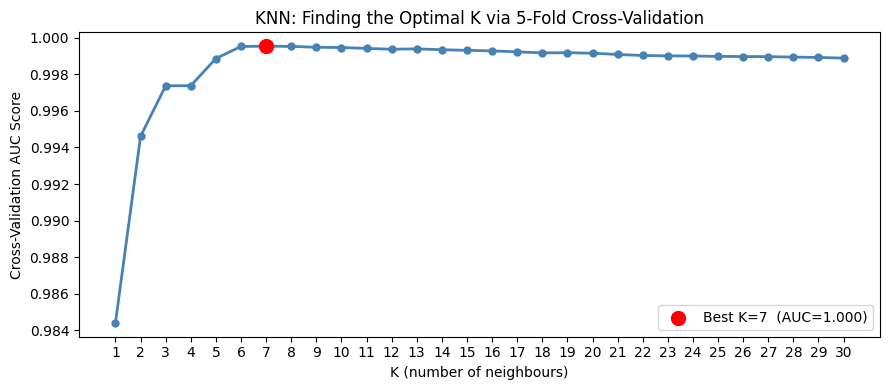

Saved: knn_k_selection.png

Bias-variance tradeoff visible in this plot:
  Low K  → high variance (wiggly, overfits training data)
  High K → high bias (too smooth, underfits)
  Best K → sweet spot in the middle


In [4]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(list(k_values), cv_scores, 'o-', color='steelblue',
        linewidth=2, markersize=5)

# Mark the best K with a red dot
ax.scatter([best_k], [max(cv_scores)], color='red', zorder=5,
           s=100, label=f'Best K={best_k}  (AUC={max(cv_scores):.3f})')

ax.set_xlabel("K (number of neighbours)")
ax.set_ylabel("Cross-Validation AUC Score")
ax.set_title("KNN: Finding the Optimal K via 5-Fold Cross-Validation")
ax.legend()
ax.set_xticks(list(k_values))
plt.tight_layout()
plt.savefig("knn_k_selection.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: knn_k_selection.png")
print()
print("Bias-variance tradeoff visible in this plot:")
print("  Low K  → high variance (wiggly, overfits training data)")
print("  High K → high bias (too smooth, underfits)")
print("  Best K → sweet spot in the middle")


In [5]:
knn_final = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean',
    weights='uniform'
)

knn_final.fit(X_train_s, y_train)

y_pred = knn_final.predict(X_test_s)

y_prob = knn_final.predict_proba(X_test_s)[:, 1]  # probability of podium

print(f"Model trained with K={best_k}")
print(f"Accuracy on test set: {accuracy_score(y_test, y_pred)*100:.1f}%")
print()

Model trained with K=7
Accuracy on test set: 99.4%



In [6]:
print("=== Classification Report ===")
print(classification_report(y_test, y_pred,
                             target_names=['No podium', 'Podium']))
print()
print("How to read this report:")
print()
print("  Precision = of all rows predicted as podium, what % actually were?")
print("              TP / (TP + FP)")
print("              High precision → few false alarms")
print()
print("  Recall    = of all actual podium rows, what % did we catch?")
print("              TP / (TP + FN)")
print("              High recall → few misses")
print()
print("  F1-score  = harmonic mean of precision and recall")
print("              2 * (precision * recall) / (precision + recall)")
print("              Best single metric when classes are imbalanced")
print()

=== Classification Report ===
              precision    recall  f1-score   support

   No podium       0.99      1.00      1.00       879
      Podium       0.99      0.97      0.98       182

    accuracy                           0.99      1061
   macro avg       0.99      0.99      0.99      1061
weighted avg       0.99      0.99      0.99      1061


How to read this report:

  Precision = of all rows predicted as podium, what % actually were?
              TP / (TP + FP)
              High precision → few false alarms

  Recall    = of all actual podium rows, what % did we catch?
              TP / (TP + FN)
              High recall → few misses

  F1-score  = harmonic mean of precision and recall
              2 * (precision * recall) / (precision + recall)
              Best single metric when classes are imbalanced



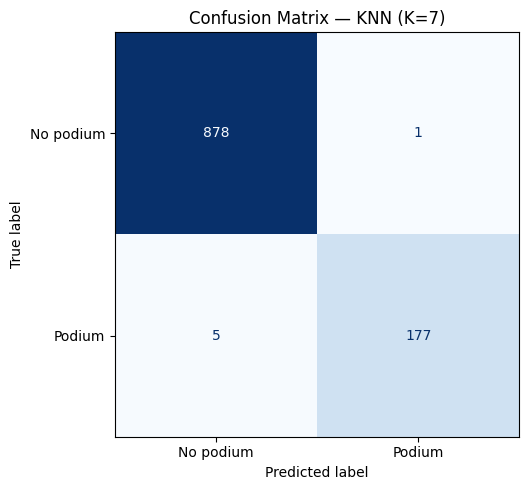

True Negatives  (TN): 878  — correctly predicted NO podium
False Positives (FP): 1  — predicted podium, was wrong
False Negatives (FN): 5  — missed actual podium finishes
True Positives  (TP): 177  — correctly predicted podium


In [7]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No podium', 'Podium'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"Confusion Matrix — KNN (K={best_k})")
plt.tight_layout()
plt.savefig("knn_confusion.png", dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN): {tn}  — correctly predicted NO podium")
print(f"False Positives (FP): {fp}  — predicted podium, was wrong")
print(f"False Negatives (FN): {fn}  — missed actual podium finishes")
print(f"True Positives  (TP): {tp}  — correctly predicted podium")


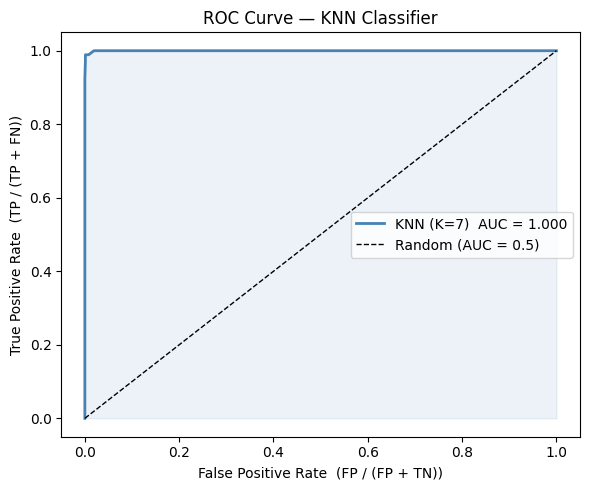

AUC Score: 1.000

AUC interpretation:
  0.90–1.00 → Excellent
  0.80–0.90 → Good
  0.70–0.80 → Fair
  0.50–0.70 → Poor


In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'KNN (K={best_k})  AUC = {auc:.3f}')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')

ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')  # shade the AUC area
ax.set_xlabel("False Positive Rate  (FP / (FP + TN))")
ax.set_ylabel("True Positive Rate  (TP / (TP + FN))")
ax.set_title("ROC Curve — KNN Classifier")
ax.legend()
plt.tight_layout()
plt.savefig("knn_roc.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC Score: {auc:.3f}")
print()
print("AUC interpretation:")
print("  0.90–1.00 → Excellent")
print("  0.80–0.90 → Good")
print("  0.70–0.80 → Fair")
print("  0.50–0.70 → Poor")


In [9]:
example_idx = 0   # pick the first test sample
x_example = X_test_s[example_idx].reshape(1, -1)

distances, indices = knn_final.kneighbors(x_example)

print(f"=== KNN trace for test sample #{example_idx} ===")
print(f"Raw features  : grid={X_test[example_idx,0]:.0f}, "
      f"laps={X_test[example_idx,1]:.0f}, "
      f"points={X_test[example_idx,2]:.0f}, "
      f"speed={X_test[example_idx,3]:.1f}")
print(f"Actual label  : {'Podium' if y_test[example_idx]==1 else 'No podium'}")
print(f"Predicted     : {'Podium' if y_pred[example_idx]==1 else 'No podium'}")
print()
print(f"The {best_k} nearest neighbours (from training set):")
print(f"  {'Neighbour':<12} {'Distance':>10} {'Label':>12}")
print("  " + "-"*38)
for rank, (dist, idx) in enumerate(zip(distances[0], indices[0]), 1):
    lbl = 'Podium' if y_train[idx] == 1 else 'No podium'
    print(f"  #{rank:<10}  {dist:>10.4f}  {lbl:>12}")

votes = {0: (y_train[indices[0]] == 0).sum(),
         1: (y_train[indices[0]] == 1).sum()}
print()
print(f"Vote count: No podium={votes[0]}, Podium={votes[1]}")
print(f"Majority vote → {'Podium' if votes[1]>votes[0] else 'No podium'}")


=== KNN trace for test sample #0 ===
Raw features  : grid=7, laps=53, points=0, speed=198.4
Actual label  : No podium
Predicted     : No podium

The 7 nearest neighbours (from training set):
  Neighbour      Distance        Label
  --------------------------------------
  #1               0.1216     No podium
  #2               0.2036     No podium
  #3               0.2171     No podium
  #4               0.2400     No podium
  #5               0.2443     No podium
  #6               0.2537     No podium
  #7               0.3619     No podium

Vote count: No podium=7, Podium=0
Majority vote → No podium


In [10]:
from sklearn.metrics import accuracy_score, roc_auc_score

print("=== KNN Final Results ===")
print(f"Best K        : {best_k}")
print(f"Accuracy      : {accuracy_score(y_test, y_pred)*100:.1f}%")
print(f"AUC Score     : {roc_auc_score(y_test, y_prob):.3f}")
print()
print("Key properties of KNN:")
print("  • Lazy learner — no training phase, just stores data")
print("  • fit() = memorise training data")
print("  • predict() = compute distances at query time → majority vote")
print("  • Must scale features (distance-based)")
print("  • Slow at prediction on large datasets (computes all distances)")
print("  • No model parameters — the data IS the model")
print()

=== KNN Final Results ===
Best K        : 7
Accuracy      : 99.4%
AUC Score     : 1.000

Key properties of KNN:
  • Lazy learner — no training phase, just stores data
  • fit() = memorise training data
  • predict() = compute distances at query time → majority vote
  • Must scale features (distance-based)
  • Slow at prediction on large datasets (computes all distances)
  • No model parameters — the data IS the model

